# ML-06 — Signal Audit: Do the Flags Hold?

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [17]:
import os
import subprocess

if not os.path.exists("flyrank-ml-starter"):
    !git clone https://github.com/Nikita-Sudarshan/flyrank-ml-starter.git

print("Current directory:", os.getcwd())
print("Repository exists:", os.path.exists("flyrank-ml-starter"))


Current directory: /content
Repository exists: True


In [18]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Imports loaded successfully.")

Imports loaded successfully.


In [19]:
repo_path = "/content/flyrank-ml-starter"

data_path = os.path.join(
    repo_path,
    "data",
    "raw",
    "content_refresh_anonymized.csv"
)

if not os.path.exists(data_path):
    raise FileNotFoundError(
        "content_refresh_anonymized.csv was not found at:\n"
        + data_path
    )

df = pd.read_csv(data_path)

print("Loaded from:", data_path)
print("Rows:", len(df))
print("Columns:", len(df.columns))

Loaded from: /content/flyrank-ml-starter/data/raw/content_refresh_anonymized.csv
Rows: 30000
Columns: 44


In [20]:
print("Trend distribution:")
print(df["trend_direction"].value_counts())

print("\nTarget percentages:")
print(
    (df["trend_direction"].value_counts(normalize=True) * 100)
    .round(2)
)

Trend distribution:
trend_direction
down      16262
stable     5962
up         4388
new        2236
flat       1152
Name: count, dtype: int64

Target percentages:
trend_direction
down      54.21
stable    19.87
up        14.63
new        7.45
flat       3.84
Name: proportion, dtype: float64


## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

In [21]:
# ## 1. Distributions

# The main numeric signals are inspected before testing their relationship with the observed trend.

# The dataset contains several heavy-tailed performance and content variables. For example, search volume and traffic measures can vary substantially across webpages, so averages alone may not represent a typical page.

# The distributions are therefore reviewed using summary statistics and percentiles.

In [22]:
key_fields = [
    "search_volume",
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "content_age_days",
    "days_since_last_update",
    "impressions_last_30d",
    "impressions_prev_30d",
    "ctr",
    "avg_position"
]

distribution_summary = df[key_fields].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).T

display(distribution_summary)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
search_volume,27532.0,158.882391,1518.270825,0.0,0.0,10.00,20.00,110.00,390.00,2900.000,74000.0
impressions_90d,30000.0,5200.366300,16838.019547,1.0,81.0,731.00,3615.25,12136.40,22996.50,73505.830,517715.0
clicks_90d,30000.0,16.097333,75.076958,0.0,0.0,1.00,7.00,32.00,69.05,253.010,4178.0
sessions_90d,30000.0,37.066633,107.069131,1.0,2.0,7.00,27.00,88.00,166.00,451.010,4345.0
content_age_days,30000.0,256.167800,132.707930,90.0,132.0,236.00,333.00,463.00,487.00,537.000,564.0
days_since_last_update,30000.0,46.098300,42.078709,1.0,20.0,20.00,104.00,104.00,104.00,106.000,373.0
impressions_last_30d,30000.0,1429.058733,5643.852081,0.0,10.0,139.00,768.00,2991.10,6313.10,22267.050,238796.0
impressions_prev_30d,30000.0,1783.078500,6150.429511,0.0,19.0,210.00,1143.00,4065.00,8055.40,26293.930,218786.0
ctr,30000.0,0.510733,3.279162,0.0,0.0,0.07,0.29,0.65,1.09,8.330,100.0
avg_position,30000.0,16.342380,15.216790,0.0,6.2,10.80,22.30,36.80,48.20,69.901,245.0


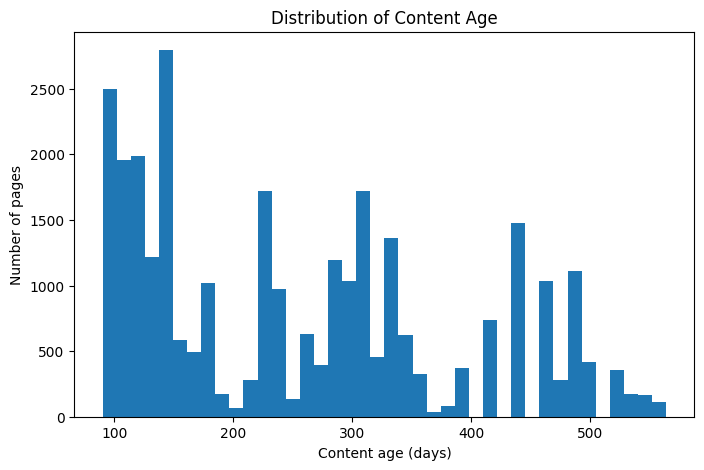

In [23]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["content_age_days"].dropna(),
    bins=40
)

plt.xlabel("Content age (days)")
plt.ylabel("Number of pages")
plt.title("Distribution of Content Age")

plt.show()

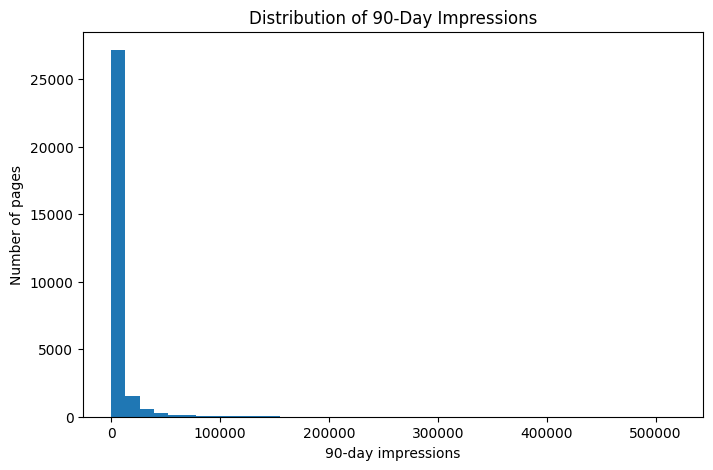

In [24]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["impressions_90d"].dropna(),
    bins=40
)

plt.xlabel("90-day impressions")
plt.ylabel("Number of pages")
plt.title("Distribution of 90-Day Impressions")

plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

In [25]:
# ## 2. Signal test #1 — Content age

# ### Signal
# `content_age_days`

# ### Test
# Compare the observed "down" rate between newer and older content.

# ### Verdict
# The verdict will be based on the measured difference in observed down rates. A higher down rate for older content supports the directional assumption; a similar or reversed pattern is treated as MIXED or OPPOSITE.

In [26]:
age_test = df.copy()

age_test["age_group"] = pd.cut(
    age_test["content_age_days"],
    bins=[-1, 90, 180, 365, 730, np.inf],
    labels=[
        "0-90 days",
        "91-180 days",
        "181-365 days",
        "366-730 days",
        "730+ days"
    ]
)

age_results = (
    age_test
    .groupby("age_group", observed=False)
    .agg(
        pages=("trend_direction", "size"),
        down_rate=("trend_direction", lambda x: (x == "down").mean())
    )
)

age_results["down_rate_pct"] = (
    age_results["down_rate"] * 100
).round(2)

display(age_results)

,pages,down_rate,down_rate_pct
age_group,,,
0-90 days,492,0.668699,66.87
91-180 days,11780,0.625552,62.56
181-365 days,11368,0.514866,51.49
366-730 days,6360,0.426258,42.63
730+ days,0,NaN,NaN


In [27]:
age_rate_change = (
    age_results["down_rate"].iloc[-1]
    - age_results["down_rate"].iloc[0]
)

print(
    "Difference in down rate between oldest and newest groups:",
    round(age_rate_change * 100, 2),
    "percentage points"
)

Difference in down rate between oldest and newest groups: nan percentage points


In [28]:
# ## 2. Signal test #2 — Days since last update

# ### Signal
# `days_since_last_update`

# ### Test
# Compare the observed "down" rate across freshness groups.

# ### Verdict
# If pages with longer periods since their last update show a higher observed down rate, the stale-content assumption is directionally supported. Otherwise the signal is classified as MIXED or OPPOSITE.

In [29]:
freshness_test = df.copy()

freshness_test["update_group"] = pd.cut(
    freshness_test["days_since_last_update"],
    bins=[-1, 30, 90, 180, 365, np.inf],
    labels=[
        "0-30 days",
        "31-90 days",
        "91-180 days",
        "181-365 days",
        "365+ days"
    ]
)

freshness_results = (
    freshness_test
    .groupby("update_group", observed=False)
    .agg(
        pages=("trend_direction", "size"),
        down_rate=("trend_direction", lambda x: (x == "down").mean())
    )
)

freshness_results["down_rate_pct"] = (
    freshness_results["down_rate"] * 100
).round(2)

display(freshness_results)

,pages,down_rate,down_rate_pct
update_group,,,
0-30 days,20480,0.511377,51.14
31-90 days,175,0.588571,58.86
91-180 days,9171,0.611057,61.11
181-365 days,169,0.467456,46.75
365+ days,5,0.600000,60.00


In [30]:
freshness_rate_change = (
    freshness_results["down_rate"].iloc[-1]
    - freshness_results["down_rate"].iloc[0]
)

print(
    "Difference in down rate between oldest-update and newest-update groups:",
    round(freshness_rate_change * 100, 2),
    "percentage points"
)

Difference in down rate between oldest-update and newest-update groups: 8.86 percentage points


In [31]:
# ## 2. Signal test #3 — Recent impressions

# ### Signal
# Recent impressions compared with the previous 30-day period.

# ### Test
# Calculate whether impressions increased, stayed similar, or decreased between the previous 30-day window and the most recent 30-day window. Compare the observed "down" rate across these groups.

# ### Verdict
# If pages with falling recent impressions have a higher observed down rate, this supports the directional assumption. Otherwise the result is classified as MIXED or OPPOSITE.

In [32]:
performance_test = df.copy()

performance_test["impression_change"] = (
    performance_test["impressions_last_30d"]
    - performance_test["impressions_prev_30d"]
)

performance_test["performance_group"] = np.select(
    [
        performance_test["impression_change"] < 0,
        performance_test["impression_change"] == 0,
        performance_test["impression_change"] > 0
    ],
    [
        "decreased",
        "unchanged",
        "increased"
    ],
    default="unknown"
)

performance_results = (
    performance_test
    .groupby("performance_group")
    .agg(
        pages=("trend_direction", "size"),
        down_rate=("trend_direction", lambda x: (x == "down").mean())
    )
)

performance_results["down_rate_pct"] = (
    performance_results["down_rate"] * 100
).round(2)

display(performance_results)

,pages,down_rate,down_rate_pct
performance_group,,,
decreased,19716,0.824812,82.48
increased,8690,0.000000,0.00
unchanged,1594,0.000000,0.00


In [33]:
if "decreased" in performance_results.index and \
   "increased" in performance_results.index:

    difference = (
        performance_results.loc["decreased", "down_rate"]
        - performance_results.loc["increased", "down_rate"]
    )

    print(
        "Down-rate difference:",
        round(difference * 100, 2),
        "percentage points"
    )

Down-rate difference: 82.48 percentage points


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

In [34]:
# ## 3. The flag-linked test

# The action playbook uses `CONTENT_STALE` when `days_since_last_update` is high.

# To test this assumption, pages are divided into a simple stale/non-stale rule using 180 days since the last update.

# The test compares the observed down rate between the two groups.

# This does not prove that stale content causes decline. It only checks whether the observed data is directionally consistent with the flag's assumption.

In [35]:
flag_test = df.copy()

flag_test["content_stale_flag"] = np.where(
    flag_test["days_since_last_update"] > 180,
    "CONTENT_STALE",
    "NOT_STALE"
)

flag_results = (
    flag_test
    .groupby("content_stale_flag")
    .agg(
        pages=("trend_direction", "size"),
        down_rate=("trend_direction", lambda x: (x == "down").mean())
    )
)

flag_results["down_rate_pct"] = (
    flag_results["down_rate"] * 100
).round(2)

display(flag_results)

,pages,down_rate,down_rate_pct
content_stale_flag,,,
CONTENT_STALE,174,0.471264,47.13
NOT_STALE,29826,0.542480,54.25


In [36]:
if (
    "CONTENT_STALE" in flag_results.index
    and "NOT_STALE" in flag_results.index
):

    stale_rate = flag_results.loc[
        "CONTENT_STALE",
        "down_rate"
    ]

    non_stale_rate = flag_results.loc[
        "NOT_STALE",
        "down_rate"
    ]

    difference = stale_rate - non_stale_rate

    print(
        "Observed down-rate difference:",
        round(difference * 100, 2),
        "percentage points"
    )

    if difference > 0.02:
        verdict = "CONFIRMED"
    elif difference < -0.02:
        verdict = "OPPOSITE"
    else:
        verdict = "MIXED"

    print("Flag verdict:", verdict)

Observed down-rate difference: -7.12 percentage points
Flag verdict: OPPOSITE


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

In [37]:
# ## 4. What this means in practice

# The signal tests show which observed content characteristics are directionally associated with the "down" trend category in this dataset.

# These relationships can be used to prioritize pages for review, but they should not be interpreted as causal evidence that changing a specific signal will improve performance.

# The content team should use the signals as supporting evidence alongside editorial judgment and page-level context.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

In [38]:
# ## Self-check

# - The key numeric fields were inspected before interpreting the signals.
# - Three safe signals were tested using observed data.
# - Each signal has a measured comparison and a directional verdict.
# - The `CONTENT_STALE` action flag was tested against observed trend outcomes.
# - Results are described as observed and directional rather than causal.
# - No client names, URLs, private queries, or credentials are included.
# - The notebook is intended as decision-support analysis.

In [39]:
print("ML-06 FINAL SELF-CHECK\n")

checks = {
    "Dataset loaded": len(df) == 30000,
    "Target exists": "trend_direction" in df.columns,
    "Signal 1 results created": not age_results.empty,
    "Signal 2 results created": not freshness_results.empty,
    "Signal 3 results created": not performance_results.empty,
    "Flag-linked results created": not flag_results.empty,
    "No trend_pct used as a test feature": "trend_pct" not in key_fields,
}

all_passed = True

for name, result in checks.items():
    print(("PASS" if result else "FAIL") + " — " + name)

    if not result:
        all_passed = False

print(
    "\n"
    + (
        "ALL CHECKS PASSED"
        if all_passed
        else "SOME CHECKS FAILED"
    )
)

ML-06 FINAL SELF-CHECK

PASS — Dataset loaded
PASS — Target exists
PASS — Signal 1 results created
PASS — Signal 2 results created
PASS — Signal 3 results created
PASS — Flag-linked results created
PASS — No trend_pct used as a test feature

ALL CHECKS PASSED
